In [1]:
# Assignment 2 - Computational Mach Learning Summer 2026: (05/04 - 08/03) (MSDS 550-01)

In [2]:
# Load Libraries

In [3]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from sklearn.model_selection import train_test_split, validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, accuracy_score, precision_score,
                             recall_score, f1_score)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries loaded.")

Libraries loaded.


In [4]:
# Load Dataset

In [5]:
DATA_PATH = r"C:\Users\cto\Desktop\MSDS550-Summer-Session\Assignment-2\healthcare-dataset-stroke-data.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "healthcare-dataset-stroke-data.csv"

df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH, "| Shape:", df.shape)
df.head()

Loaded: C:\Users\cto\Desktop\MSDS550-Summer-Session\Assignment-2\healthcare-dataset-stroke-data.csv | Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [7]:
print("Missing values per column:")
print(df.isnull().sum()[lambda s: s > 0])
print("\nTarget distribution:")
print(df["stroke"].value_counts())
print((df["stroke"].value_counts(normalize=True) * 100).round(2).astype(str) + " %")

Missing values per column:
bmi    201
dtype: int64

Target distribution:
stroke
0    4861
1     249
Name: count, dtype: int64
stroke
0    95.13 %
1     4.87 %
Name: proportion, dtype: object


In [8]:
# Data Visualization

In [9]:
eda = df.drop(columns="id").copy()
eda["bmi"] = eda["bmi"].fillna(eda["bmi"].median())
num_cols = ["age", "avg_glucose_level", "bmi"]
cat_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

In [10]:
# Target Distribution

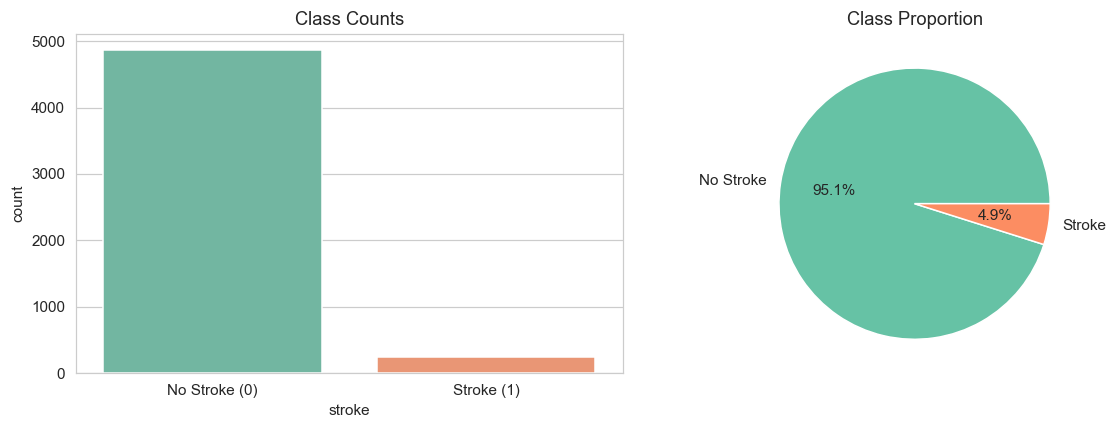

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x="stroke", data=eda, ax=ax[0], order=[0, 1], palette="Set2")
ax[0].set_title("Class Counts"); ax[0].set_xticklabels(["No Stroke (0)", "Stroke (1)"])
eda["stroke"].value_counts(normalize=True).reindex([0, 1]).plot.pie(
    autopct="%1.1f%%", labels=["No Stroke", "Stroke"],
    colors=sns.color_palette("Set2"), ax=ax[1])
ax[1].set_ylabel(""); ax[1].set_title("Class Proportion")
plt.tight_layout(); plt.show()

In [12]:
# Distributions of Numeric Features

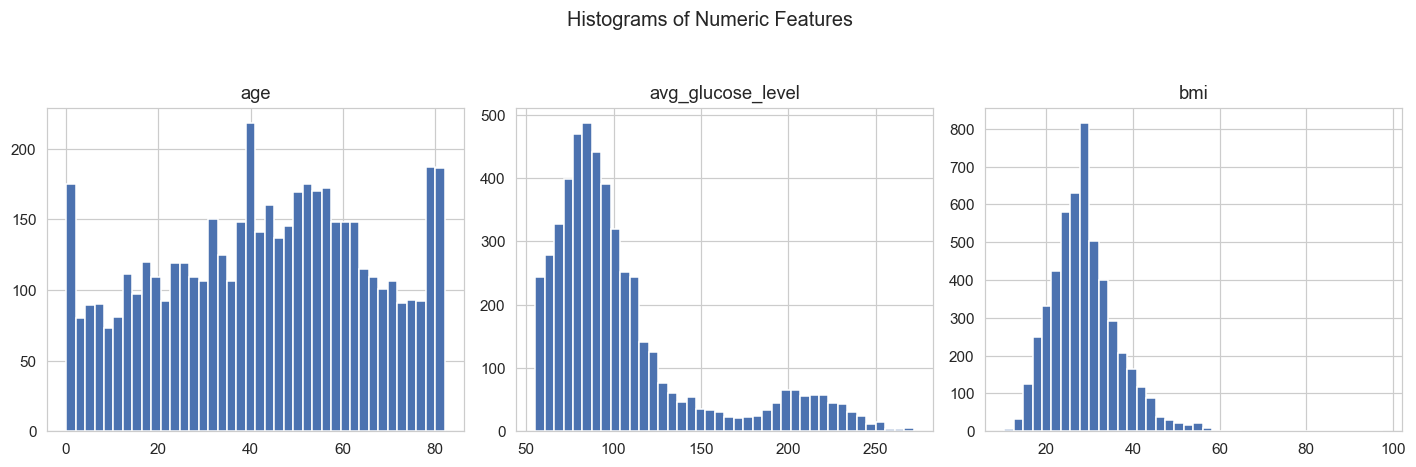

In [13]:
eda[num_cols].hist(bins=40, figsize=(13, 4), color="#4C72B0", edgecolor="white", layout=(1, 3))
plt.suptitle("Histograms of Numeric Features", y=1.05, fontsize=13)
plt.tight_layout(); plt.show()

In [14]:
# Numeric Features by Stroke Status (Box Plots)

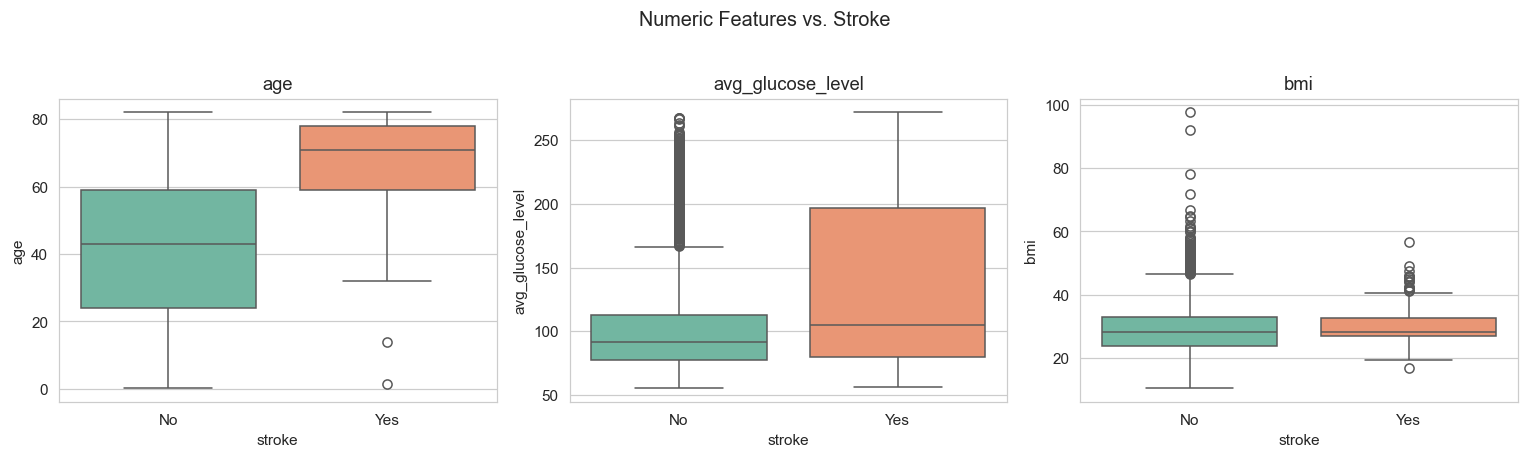

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(num_cols):
    sns.boxplot(x="stroke", y=col, data=eda, ax=axes[i], palette="Set2")
    axes[i].set_xticklabels(["No", "Yes"]); axes[i].set_title(col)
plt.suptitle("Numeric Features vs. Stroke", y=1.03, fontsize=13)
plt.tight_layout(); plt.show()

In [16]:
# Categorical Features (stroke rate within each level)

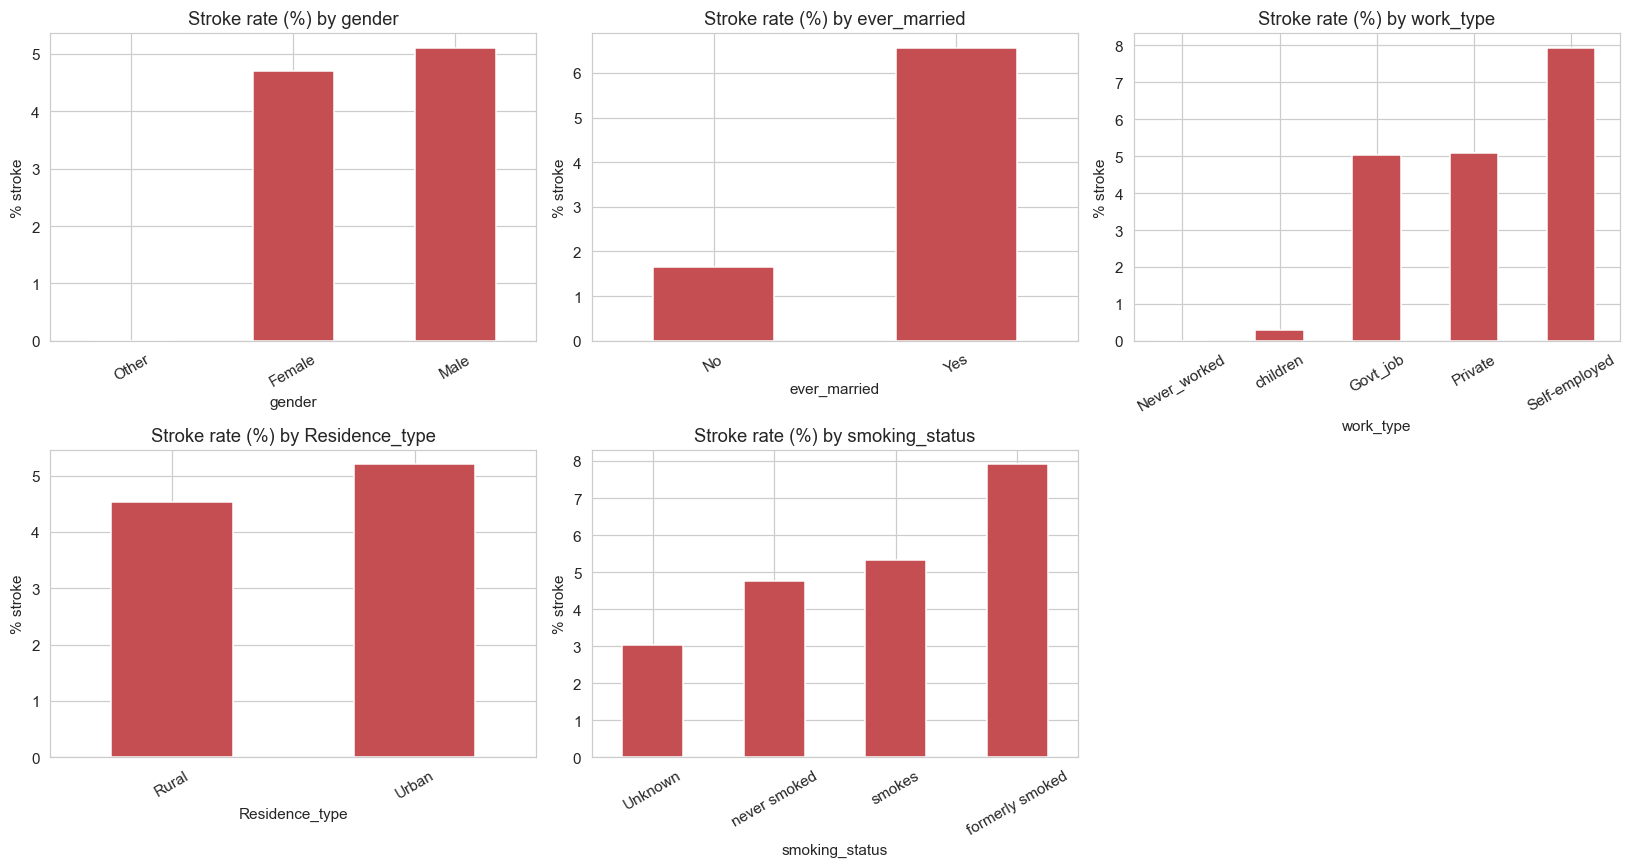

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), cat_cols):
    (eda.groupby(col)["stroke"].mean() * 100).sort_values().plot.bar(
        ax=ax, color="#C44E52")
    ax.set_title(f"Stroke rate (%) by {col}"); ax.set_ylabel("% stroke")
    ax.tick_params(axis="x", rotation=30)
axes.ravel()[-1].axis("off")
plt.tight_layout(); plt.show()

In [18]:
# Correlation Heatmap

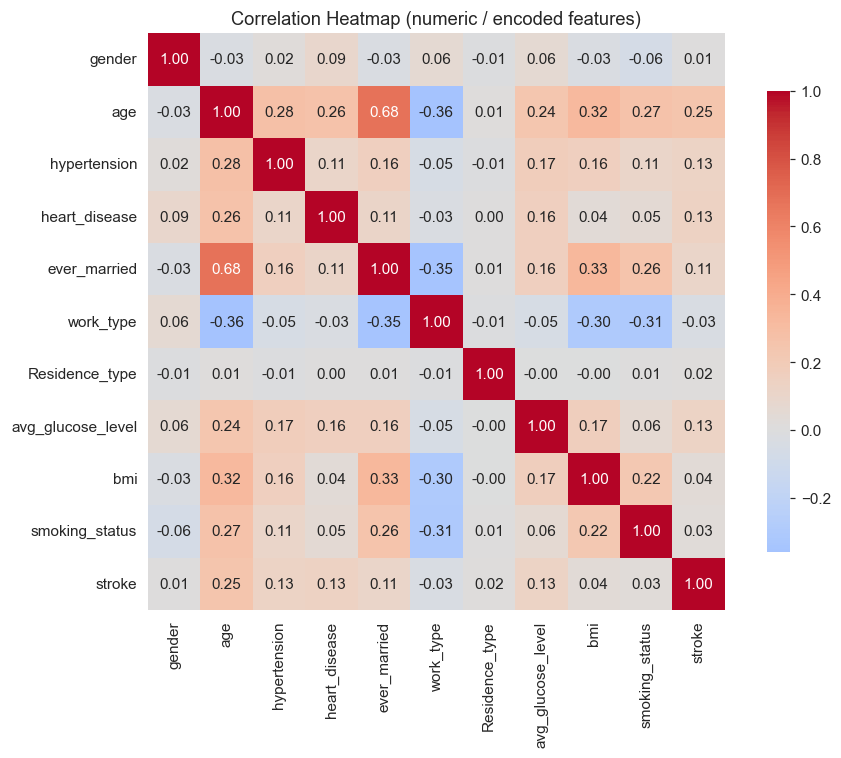

In [19]:
corr = eda.copy()
for c in cat_cols:
    corr[c] = corr[c].astype("category").cat.codes
plt.figure(figsize=(9, 7))
sns.heatmap(corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Heatmap (numeric / encoded features)")
plt.tight_layout(); plt.show()

In [20]:
# Preprocessing, Split & SMOTE

In [21]:
data = df.drop(columns="id").copy()

n_other = (data["gender"] == "Other").sum()
n_never = (data["work_type"] == "Never_worked").sum()
data = data[(data["gender"] != "Other") & (data["work_type"] != "Never_worked")].reset_index(drop=True)
print(f"Removed {n_other} 'Other' gender + {n_never} 'Never_worked' rows -> {data.shape[0]} rows")

data = pd.get_dummies(data, columns=cat_cols, drop_first=True)
bool_cols = data.select_dtypes("bool").columns
data[bool_cols] = data[bool_cols].astype(int)

X = data.drop(columns="stroke")
y = data["stroke"]
feature_names = X.columns.tolist()
print("Feature count:", len(feature_names))

Removed 1 'Other' gender + 22 'Never_worked' rows -> 5087 rows
Feature count: 14


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

bmi_median = X_train["bmi"].median()
X_train["bmi"] = X_train["bmi"].fillna(bmi_median)
X_test["bmi"]  = X_test["bmi"].fillna(bmi_median)
print(f"Imputed bmi with training median = {bmi_median:.1f}")

scaler = StandardScaler().fit(X_train)
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=feature_names, index=X_train.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),  columns=feature_names, index=X_test.index)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train positives: %d (%.2f%%) | Test positives: %d (%.2f%%)"
      % (y_train.sum(), 100*y_train.mean(), y_test.sum(), 100*y_test.mean()))

Imputed bmi with training median = 28.0
Train: (4069, 14) | Test: (1018, 14)
Train positives: 199 (4.89%) | Test positives: 50 (4.91%)


In [23]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res,   y_train_res   = smote.fit_resample(X_train,   y_train)
X_train_s_res, y_train_s_res = smote.fit_resample(X_train_s, y_train)
print("After SMOTE -> class counts:", np.bincount(y_train_res))

After SMOTE -> class counts: [3870 3870]


In [24]:
# Shared Evaluation Helpers

In [25]:
results = []

def evaluate_model(name, y_true, y_pred, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    row = {
        "Model": name,
        "Accuracy":    accuracy_score(y_true, y_pred),
        "Precision":   precision_score(y_true, y_pred, zero_division=0),
        "Recall":      recall_score(y_true, y_pred),
        "F1-score":    f1_score(y_true, y_pred, zero_division=0),
        "Sensitivity": tp / (tp + fn) if (tp + fn) else 0,
        "Specificity": tn / (tn + fp) if (tn + fp) else 0,
        "ROC-AUC":     roc_auc,
    }
    results.append(row)
    print(f"--- {name} ---")
    for k, v in row.items():
        if k != "Model":
            print(f"{k:12s}: {v:.4f}")
    return row, (fpr, tpr, roc_auc)


def plot_cm_roc(name, y_true, y_pred, y_proba):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["No Stroke", "Stroke"]).plot(
        ax=ax[0], cmap="Blues", colorbar=False)
    ax[0].set_title(f"{name} - Confusion Matrix")
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    ax[1].plot(fpr, tpr, color="#C44E52", lw=2, label=f"AUC = {roc_auc:.3f}")
    ax[1].plot([0, 1], [0, 1], "k--", lw=1)
    ax[1].set_xlabel("False Positive Rate"); ax[1].set_ylabel("True Positive Rate")
    ax[1].set_title(f"{name} - ROC Curve"); ax[1].legend(loc="lower right")
    plt.tight_layout(); plt.show()

roc_store = {}
print("Helpers ready.")

Helpers ready.


In [26]:
# Logistic Regression - Coefficients & P-Value Table

In [27]:
X_train_sm = sm.add_constant(X_train_s)            
logit_model = sm.Logit(y_train, X_train_sm).fit(disp=0, maxiter=300)

conf = logit_model.conf_int(); conf.columns = ["CI 2.5%", "CI 97.5%"]
pval_table = pd.DataFrame({
    "Coefficient": logit_model.params,
    "Std. Error":  logit_model.bse,
    "z-value":     logit_model.tvalues,
    "P-value":     logit_model.pvalues,
}).join(conf)
pval_table["Odds Ratio"] = np.exp(logit_model.params)
pval_table["Significant (p<0.05)"] = np.where(pval_table["P-value"] < 0.05, "Yes", "No")

print("Converged:", logit_model.mle_retvals["converged"],
      "| Pseudo R^2:", round(logit_model.prsquared, 4))
pval_table.round(4)

Converged: True | Pseudo R^2: 0.2037


,Coefficient,Std. Error,z-value,P-value,CI 2.5%,CI 97.5%,Odds Ratio,Significant (p<0.05)
const,-3.9412,0.1541,-25.5789,0.0000,-4.2432,-3.6392,0.0194,Yes
age,1.6971,0.1471,11.5377,0.0000,1.4088,1.9853,5.4579,Yes
hypertension,0.1203,0.0553,2.1754,0.0296,0.0119,0.2286,1.1278,Yes
heart_disease,0.0574,0.0484,1.1868,0.2353,-0.0374,0.1522,1.0591,No
avg_glucose_level,0.1719,0.0605,2.8411,0.0045,0.0533,0.2905,1.1876,Yes
bmi,0.0404,0.0966,0.4187,0.6754,-0.1488,0.2297,1.0413,No
gender_Male,0.0519,0.0777,0.6674,0.5045,-0.1005,0.2042,1.0532,No
ever_married_Yes,-0.0827,0.1213,-0.6818,0.4953,-0.3204,0.1550,0.9206,No
work_type_Private,0.0152,0.1105,0.1372,0.8909,-0.2015,0.2318,1.0153,No
work_type_Self-employed,-0.1024,0.0929,-1.1018,0.2705,-0.2845,0.0797,0.9027,No


In [28]:
# =====================================================================
#  IN-DEPTH LOGISTIC REGRESSION COEFFICIENT / P-VALUE TABLE
#  (fit on the original, non-SMOTE standardized training data)
# =====================================================================
from statsmodels.stats.outliers_influence import variance_inflation_factor

ci = logit_model.conf_int(); ci.columns = ["ci_low", "ci_high"]

def sig_stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "." if p < 0.10 else "ns"

def sig_band(p):
    if p < 0.001: return "Highly significant (p<0.001)"
    if p < 0.01:  return "Very significant (p<0.01)"
    if p < 0.05:  return "Significant (p<0.05)"
    if p < 0.10:  return "Borderline (0.05–0.10)"
    return "Not significant (p>=0.10)"

pval_depth = pd.DataFrame({
    "Coef (log-odds)":  logit_model.params,
    "Std. Error":       logit_model.bse,
    "z-value":          logit_model.tvalues,
    "P-value":          logit_model.pvalues,
    "Signif.":          logit_model.pvalues.map(sig_stars),
    "CI low (log-odds)":  ci["ci_low"],
    "CI high (log-odds)": ci["ci_high"],
    "Odds Ratio":       np.exp(logit_model.params),
    "OR CI low":        np.exp(ci["ci_low"]),
    "OR CI high":       np.exp(ci["ci_high"]),
    "% change in odds": (np.exp(logit_model.params) - 1) * 100,
    "Significance band": logit_model.pvalues.map(sig_band),
})

# Variance Inflation Factor (multicollinearity check) — uses the design matrix
pval_depth["VIF"] = pd.Series(
    {col: variance_inflation_factor(X_train_sm.values, i)
     for i, col in enumerate(X_train_sm.columns)})

pval_depth = pval_depth.sort_values("P-value")

# Pretty display: scientific notation for tiny p-values, colour by significance
def shade(row):
    p = row["P-value"]
    c = ("#b7e1cd" if p < 0.001 else "#d9ead3" if p < 0.01 else
         "#fff2cc" if p < 0.05 else "#fce5cd" if p < 0.10 else "#f4cccc")
    return [f"background-color: {c}"] * len(row)

pval_depth.style.apply(shade, axis=1).format({
    "Coef (log-odds)": "{:.4f}", "Std. Error": "{:.4f}", "z-value": "{:.3f}",
    "P-value": "{:.3e}", "CI low (log-odds)": "{:.4f}", "CI high (log-odds)": "{:.4f}",
    "Odds Ratio": "{:.3f}", "OR CI low": "{:.3f}", "OR CI high": "{:.3f}",
    "% change in odds": "{:+.1f}%", "VIF": "{:.2f}",
})

,Coef (log-odds),Std. Error,z-value,P-value,Signif.,CI low (log-odds),CI high (log-odds),Odds Ratio,OR CI low,OR CI high,% change in odds,Significance band,VIF
const,-3.9412,0.1541,-25.579,2.620e-144,***,-4.2432,-3.6392,0.019,0.014,0.026,-98.1%,Highly significant (p<0.001),1.00
age,1.6971,0.1471,11.538,8.518e-31,***,1.4088,1.9853,5.458,4.091,7.282,+445.8%,Highly significant (p<0.001),2.88
avg_glucose_level,0.1719,0.0605,2.841,4.496e-03,**,0.0533,0.2905,1.188,1.055,1.337,+18.8%,Very significant (p<0.01),1.10
hypertension,0.1203,0.0553,2.175,2.960e-02,*,0.0119,0.2286,1.128,1.012,1.257,+12.8%,Significant (p<0.05),1.12
work_type_children,0.3531,0.2968,1.190,2.341e-01,ns,-0.2285,0.9348,1.424,0.796,2.547,+42.4%,Not significant (p>=0.10),3.24
heart_disease,0.0574,0.0484,1.187,2.353e-01,ns,-0.0374,0.1522,1.059,0.963,1.164,+5.9%,Not significant (p>=0.10),1.10
smoking_status_never smoked,-0.1243,0.1068,-1.164,2.445e-01,ns,-0.3337,0.0850,0.883,0.716,1.089,-11.7%,Not significant (p>=0.10),1.81
work_type_Self-employed,-0.1024,0.0929,-1.102,2.705e-01,ns,-0.2845,0.0797,0.903,0.752,1.083,-9.7%,Not significant (p>=0.10),1.92
Residence_type_Urban,0.0840,0.0778,1.079,2.807e-01,ns,-0.0686,0.2365,1.088,0.934,1.267,+8.8%,Not significant (p>=0.10),1.00
smoking_status_smokes,0.0691,0.0923,0.748,4.542e-01,ns,-0.1119,0.2501,1.072,0.894,1.284,+7.2%,Not significant (p>=0.10),1.55


In [29]:
print("MODEL-LEVEL FIT DIAGNOSTICS")
print(f"  Observations (n)      : {int(logit_model.nobs)}")
print(f"  Log-Likelihood        : {logit_model.llf:.2f}")
print(f"  Null Log-Likelihood   : {logit_model.llnull:.2f}")
print(f"  McFadden Pseudo R²     : {logit_model.prsquared:.4f}")
print(f"  LLR p-value (overall) : {logit_model.llr_pvalue:.3e}")
print(f"  AIC / BIC             : {logit_model.aic:.1f} / {logit_model.bic:.1f}")
n_sig = (logit_model.pvalues < 0.05).sum() - 1   # exclude intercept
print(f"  Significant predictors: {n_sig} of {len(logit_model.params)-1}")

MODEL-LEVEL FIT DIAGNOSTICS
  Observations (n)      : 4069
  Log-Likelihood        : -632.74
  Null Log-Likelihood   : -794.60
  McFadden Pseudo R²     : 0.2037
  LLR p-value (overall) : 1.313e-60
  AIC / BIC             : 1295.5 / 1390.2
  Significant predictors: 3 of 14


In [30]:
print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:                 stroke   No. Observations:                 4069
Model:                          Logit   Df Residuals:                     4054
Method:                           MLE   Df Model:                           14
Date:                Tue, 30 Jun 2026   Pseudo R-squ.:                  0.2037
Time:                        13:59:51   Log-Likelihood:                -632.74
converged:                       True   LL-Null:                       -794.60
Covariance Type:            nonrobust   LLR p-value:                 1.313e-60
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -3.9412      0.154    -25.579      0.000      -4.243      -3.639
age                                1.6971      0.147     11.538      0.

In [31]:
# Prediction, ROC & Confusion Matrix

--- Logistic Regression ---
Accuracy    : 0.7063
Precision   : 0.1261
Recall      : 0.8400
F1-score    : 0.2193
Sensitivity : 0.8400
Specificity : 0.6994
ROC-AUC     : 0.8445


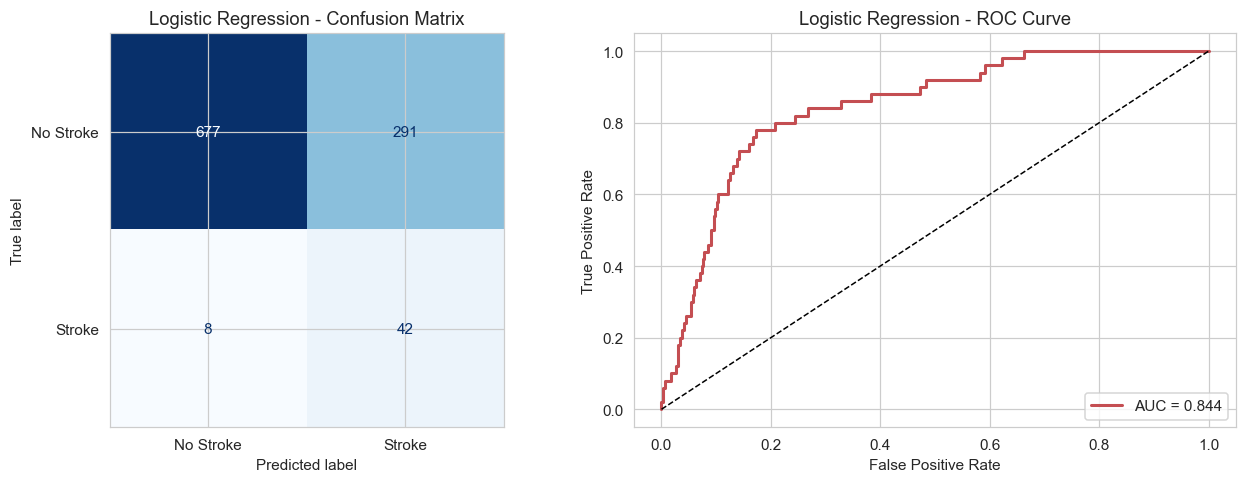

In [32]:
lr = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
lr.fit(X_train_s_res, y_train_s_res)
lr_pred  = lr.predict(X_test_s)
lr_proba = lr.predict_proba(X_test_s)[:, 1]
_, roc = evaluate_model("Logistic Regression", y_test, lr_pred, lr_proba)
roc_store["Logistic Regression"] = roc
plot_cm_roc("Logistic Regression", y_test, lr_pred, lr_proba)

In [33]:
# Decision Tree - Hyperparameter Exploration

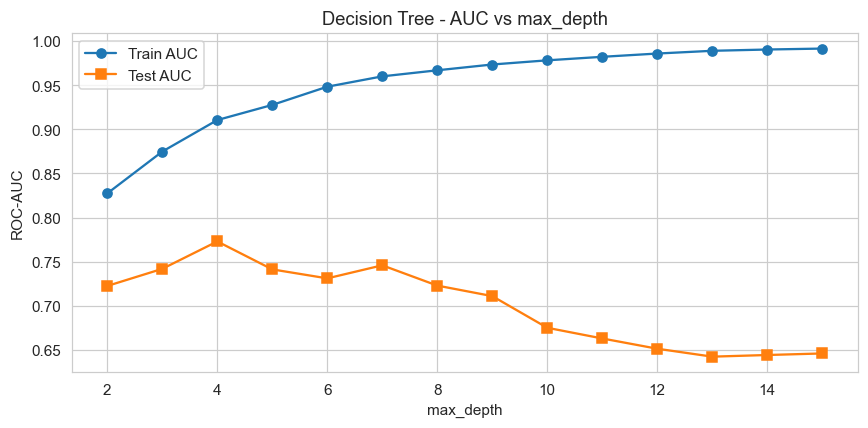

Best max_depth by test AUC: 4


In [34]:
depths = range(2, 16)
train_auc, test_auc = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, min_samples_split=20,
                               random_state=RANDOM_STATE).fit(X_train_res, y_train_res)
    train_auc.append(auc(*roc_curve(y_train_res, m.predict_proba(X_train_res)[:, 1])[:2]))
    test_auc.append(auc(*roc_curve(y_test, m.predict_proba(X_test)[:, 1])[:2]))

plt.figure(figsize=(8, 4))
plt.plot(list(depths), train_auc, "o-", label="Train AUC")
plt.plot(list(depths), test_auc, "s-", label="Test AUC")
plt.xlabel("max_depth"); plt.ylabel("ROC-AUC")
plt.title("Decision Tree - AUC vs max_depth"); plt.legend(); plt.tight_layout(); plt.show()
best_depth = list(depths)[int(np.argmax(test_auc))]
print("Best max_depth by test AUC:", best_depth)

--- Decision Tree (depth=4) ---
Accuracy    : 0.8153
Precision   : 0.1515
Recall      : 0.6000
F1-score    : 0.2419
Sensitivity : 0.6000
Specificity : 0.8264
ROC-AUC     : 0.7729


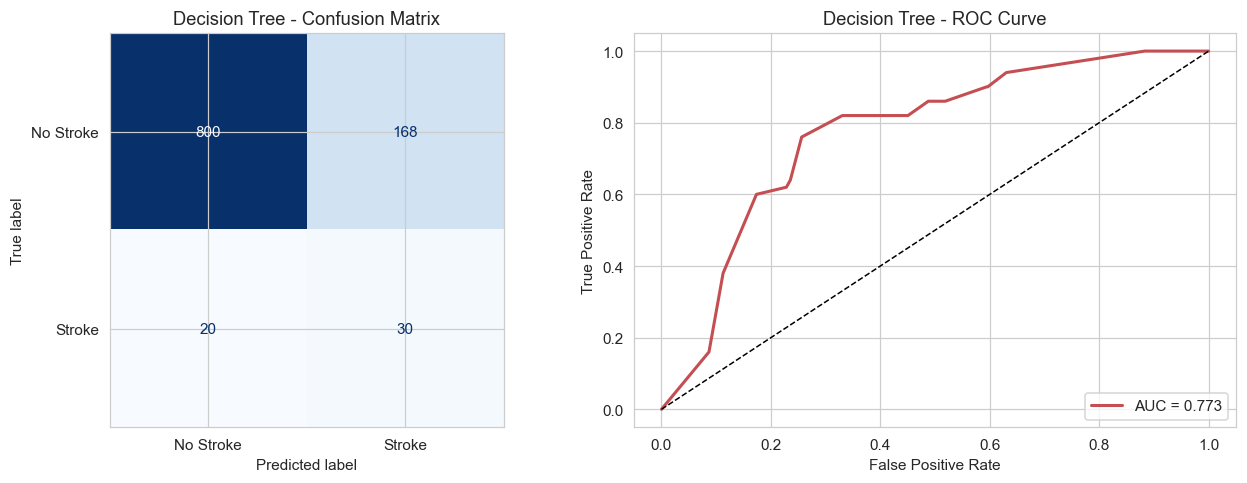

In [35]:
dt = DecisionTreeClassifier(max_depth=best_depth, min_samples_split=20,
                            random_state=RANDOM_STATE)
dt.fit(X_train_res, y_train_res)
dt_pred  = dt.predict(X_test)
dt_proba = dt.predict_proba(X_test)[:, 1]
_, roc = evaluate_model(f"Decision Tree (depth={best_depth})", y_test, dt_pred, dt_proba)
roc_store["Decision Tree"] = roc
plot_cm_roc("Decision Tree", y_test, dt_pred, dt_proba)

In [36]:
# Decision Tree Structure

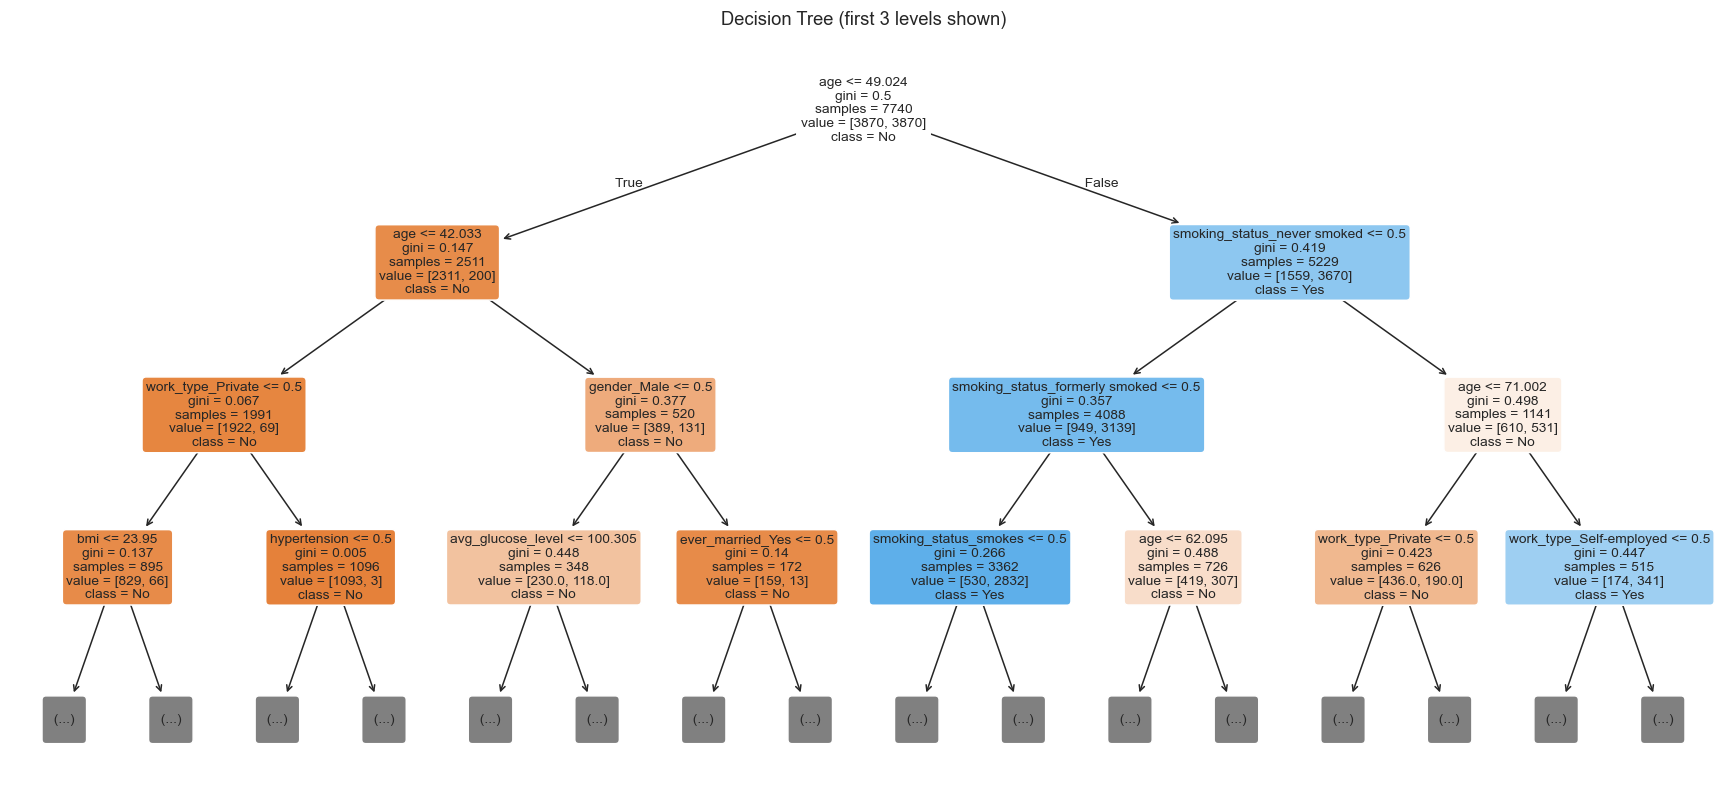

In [37]:
plt.figure(figsize=(20, 9))
plot_tree(dt, max_depth=3, feature_names=feature_names,
          class_names=["No", "Yes"], filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree (first 3 levels shown)"); plt.show()

In [38]:
# Feature Importance 

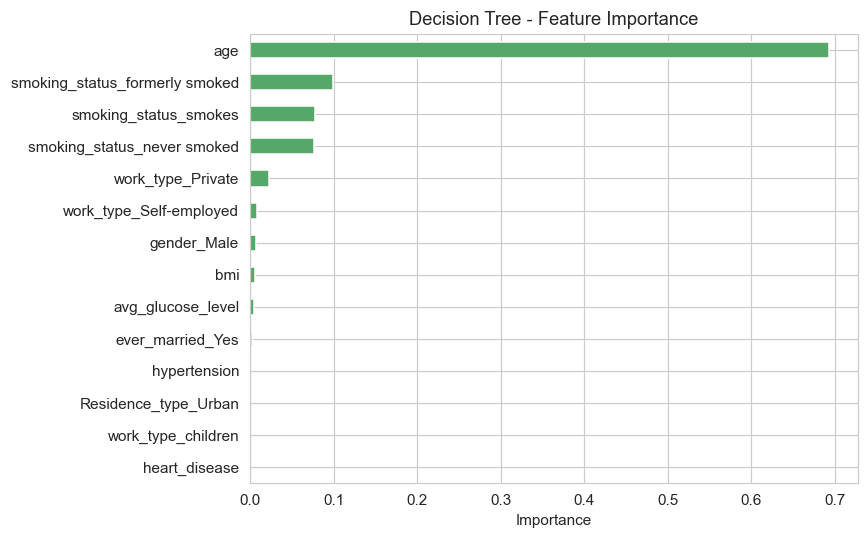

In [39]:
def plot_importance(importances, title):
    imp = pd.Series(importances, index=feature_names).sort_values()
    plt.figure(figsize=(8, 5)); imp.plot.barh(color="#55A868")
    plt.title(title); plt.xlabel("Importance"); plt.tight_layout(); plt.show()
    return imp
_ = plot_importance(dt.feature_importances_, "Decision Tree - Feature Importance")

In [40]:
# Random Forest

--- Random Forest ---
Accuracy    : 0.8861
Precision   : 0.1071
Recall      : 0.1800
F1-score    : 0.1343
Sensitivity : 0.1800
Specificity : 0.9225
ROC-AUC     : 0.7730


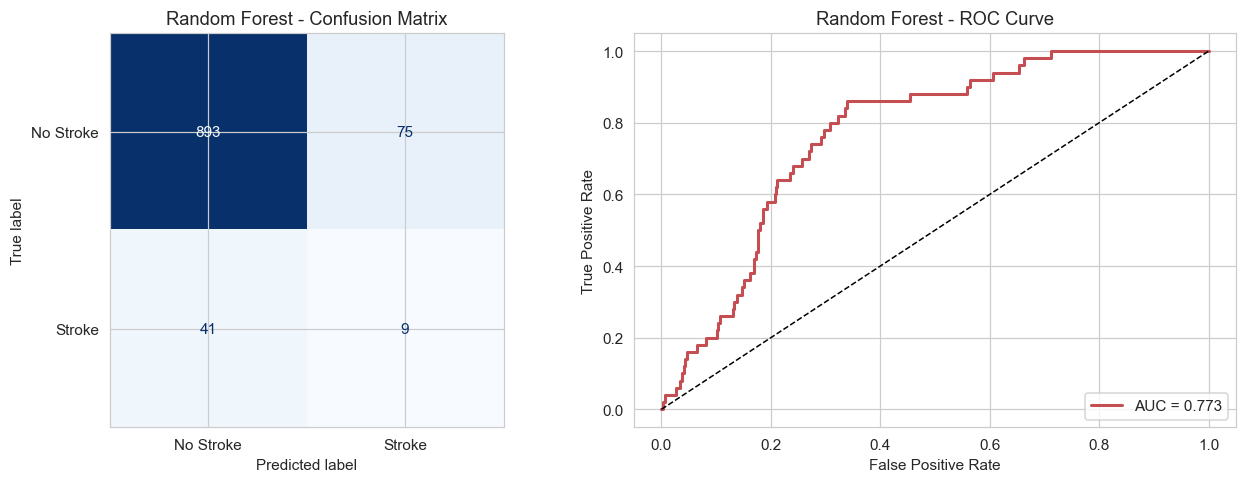

In [41]:
rf = RandomForestClassifier(n_estimators=300, max_depth=12,
                            min_samples_split=10, n_jobs=-1,
                            random_state=RANDOM_STATE)
rf.fit(X_train_res, y_train_res)
rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
_, roc = evaluate_model("Random Forest", y_test, rf_pred, rf_proba)
roc_store["Random Forest"] = roc
plot_cm_roc("Random Forest", y_test, rf_pred, rf_proba)

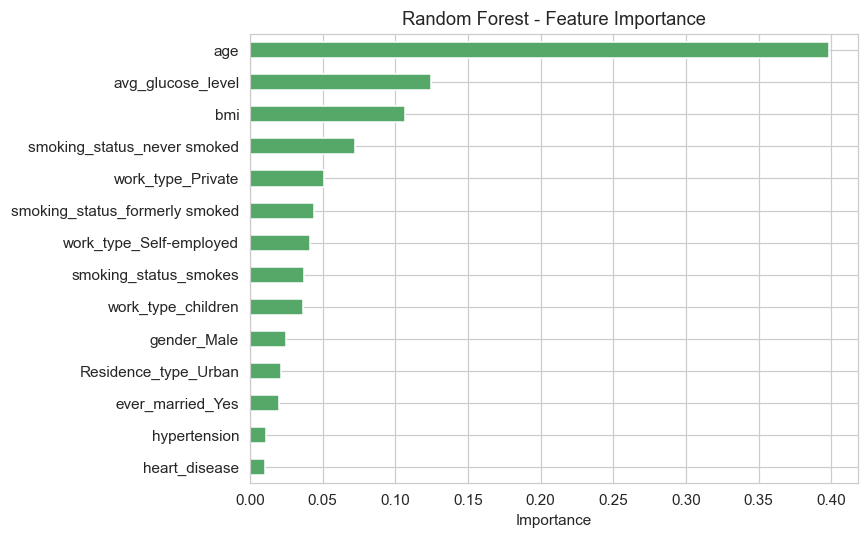

In [42]:
_ = plot_importance(rf.feature_importances_, "Random Forest - Feature Importance")

In [43]:
# AdaBoost

--- AdaBoost ---
Accuracy    : 0.8330
Precision   : 0.1471
Recall      : 0.5000
F1-score    : 0.2273
Sensitivity : 0.5000
Specificity : 0.8502
ROC-AUC     : 0.7643


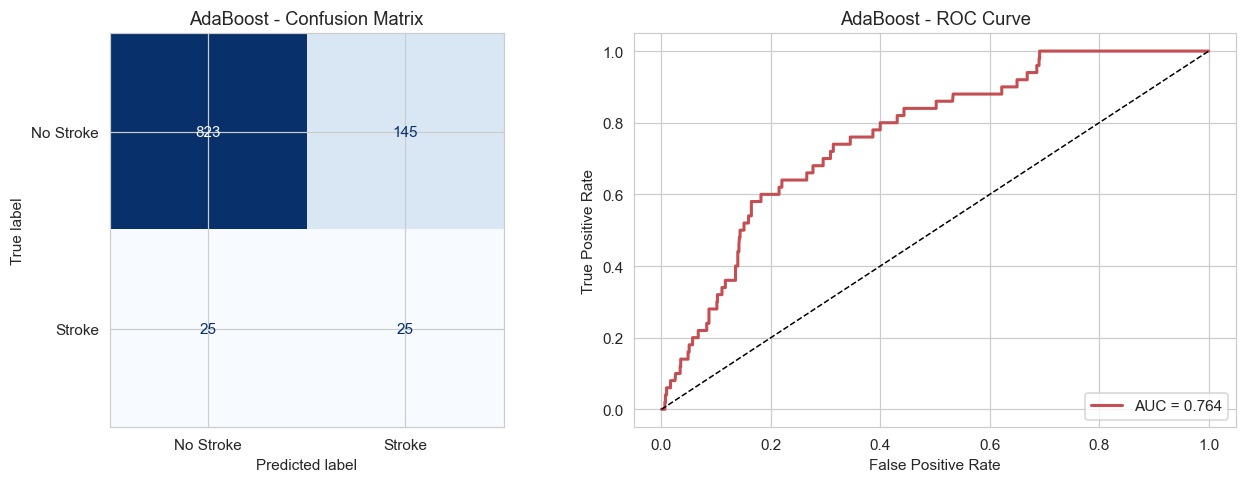

In [44]:
ada = AdaBoostClassifier(n_estimators=200, learning_rate=1.0, random_state=RANDOM_STATE)
ada.fit(X_train_res, y_train_res)
ada_pred  = ada.predict(X_test)
ada_proba = ada.predict_proba(X_test)[:, 1]
_, roc = evaluate_model("AdaBoost", y_test, ada_pred, ada_proba)
roc_store["AdaBoost"] = roc
plot_cm_roc("AdaBoost", y_test, ada_pred, ada_proba)

In [45]:
# Gradient Boosting

--- Gradient Boosting ---
Accuracy    : 0.8811
Precision   : 0.1485
Recall      : 0.3000
F1-score    : 0.1987
Sensitivity : 0.3000
Specificity : 0.9112
ROC-AUC     : 0.7318


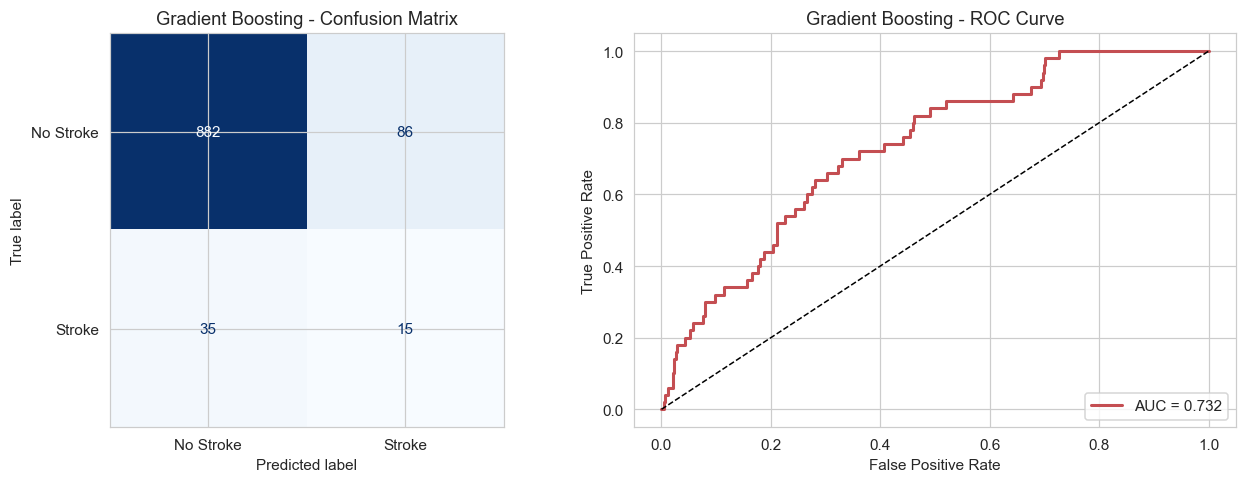

In [46]:
gb = GradientBoostingClassifier(n_estimators=300, learning_rate=0.1,
                                max_depth=3, random_state=RANDOM_STATE)
gb.fit(X_train_res, y_train_res)
gb_pred  = gb.predict(X_test)
gb_proba = gb.predict_proba(X_test)[:, 1]
_, roc = evaluate_model("Gradient Boosting", y_test, gb_pred, gb_proba)
roc_store["Gradient Boosting"] = roc
plot_cm_roc("Gradient Boosting", y_test, gb_pred, gb_proba)

In [47]:
# XGBoost

--- XGBoost ---
Accuracy    : 0.8870
Precision   : 0.1505
Recall      : 0.2800
F1-score    : 0.1958
Sensitivity : 0.2800
Specificity : 0.9184
ROC-AUC     : 0.7629


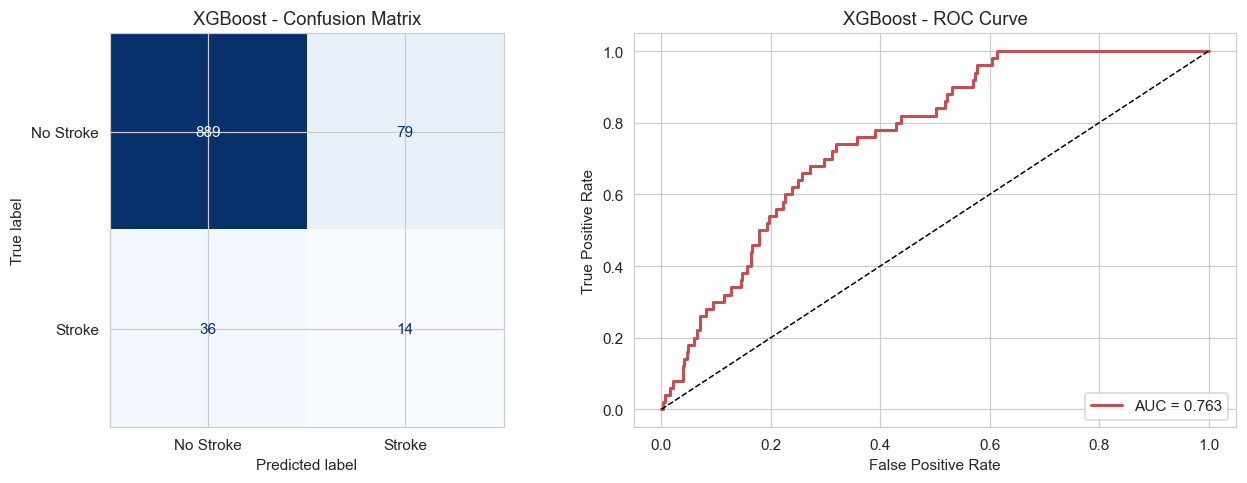

In [48]:
xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                    subsample=0.9, colsample_bytree=0.9,
                    eval_metric="logloss", random_state=RANDOM_STATE)
xgb.fit(X_train_res, y_train_res)
xgb_pred  = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]
_, roc = evaluate_model("XGBoost", y_test, xgb_pred, xgb_proba)
roc_store["XGBoost"] = roc
plot_cm_roc("XGBoost", y_test, xgb_pred, xgb_proba)

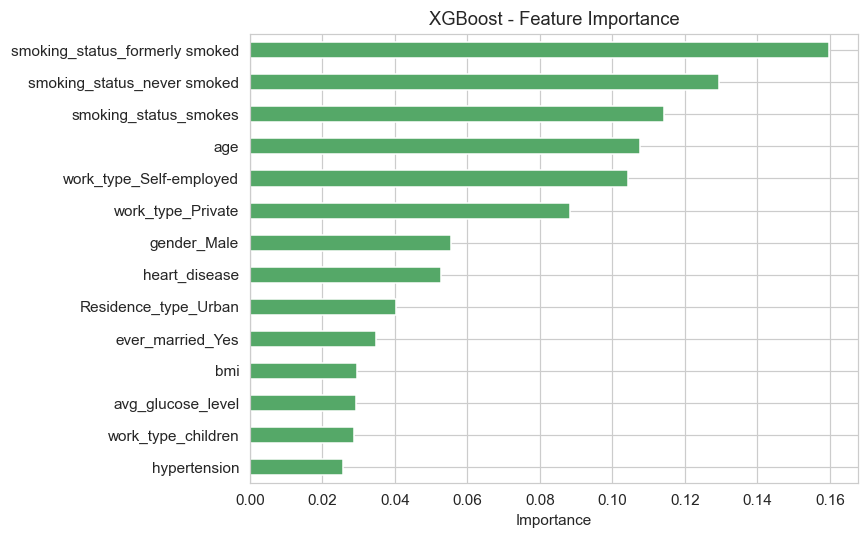

In [49]:
_ = plot_importance(xgb.feature_importances_, "XGBoost - Feature Importance")

In [50]:
# K-Nearest Neighbors (KNN)

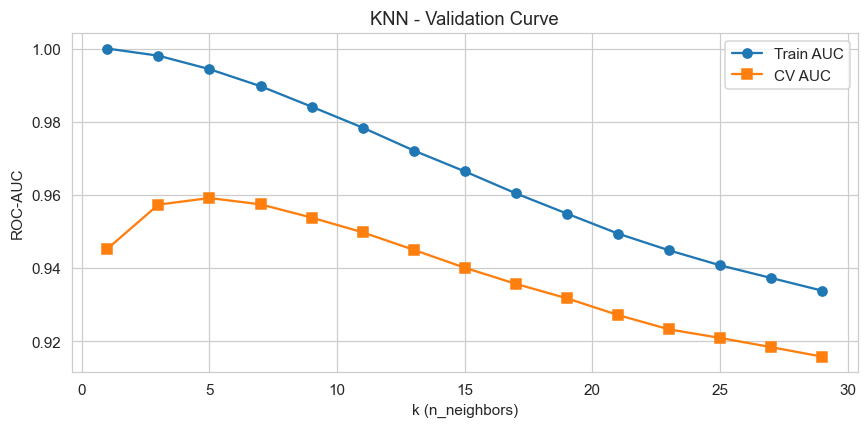

Best k by CV AUC: 5


In [51]:
k_range = range(1, 31, 2)
train_scores, val_scores = validation_curve(
    KNeighborsClassifier(), X_train_s_res, y_train_s_res,
    param_name="n_neighbors", param_range=list(k_range),
    cv=4, scoring="roc_auc", n_jobs=-1)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), train_scores.mean(axis=1), "o-", label="Train AUC")
plt.plot(list(k_range), val_scores.mean(axis=1), "s-", label="CV AUC")
plt.xlabel("k (n_neighbors)"); plt.ylabel("ROC-AUC")
plt.title("KNN - Validation Curve"); plt.legend(); plt.tight_layout(); plt.show()
best_k = list(k_range)[int(np.argmax(val_scores.mean(axis=1)))]
print("Best k by CV AUC:", best_k)

--- KNN (k=5) ---
Accuracy    : 0.8055
Precision   : 0.0843
Recall      : 0.3000
F1-score    : 0.1316
Sensitivity : 0.3000
Specificity : 0.8316
ROC-AUC     : 0.6691


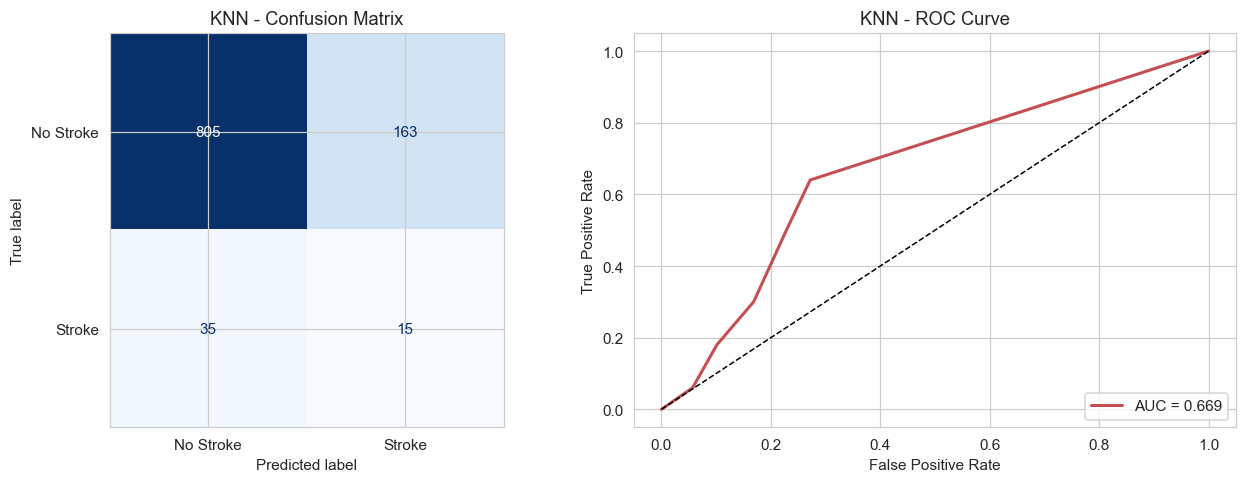

In [52]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_s_res, y_train_s_res)
knn_pred  = knn.predict(X_test_s)
knn_proba = knn.predict_proba(X_test_s)[:, 1]
_, roc = evaluate_model(f"KNN (k={best_k})", y_test, knn_pred, knn_proba)
roc_store["KNN"] = roc
plot_cm_roc("KNN", y_test, knn_pred, knn_proba)

In [53]:
# Naïve Bayes 

--- Naive Bayes ---
Accuracy    : 0.6012
Precision   : 0.0917
Recall      : 0.8000
F1-score    : 0.1646
Sensitivity : 0.8000
Specificity : 0.5909
ROC-AUC     : 0.7932


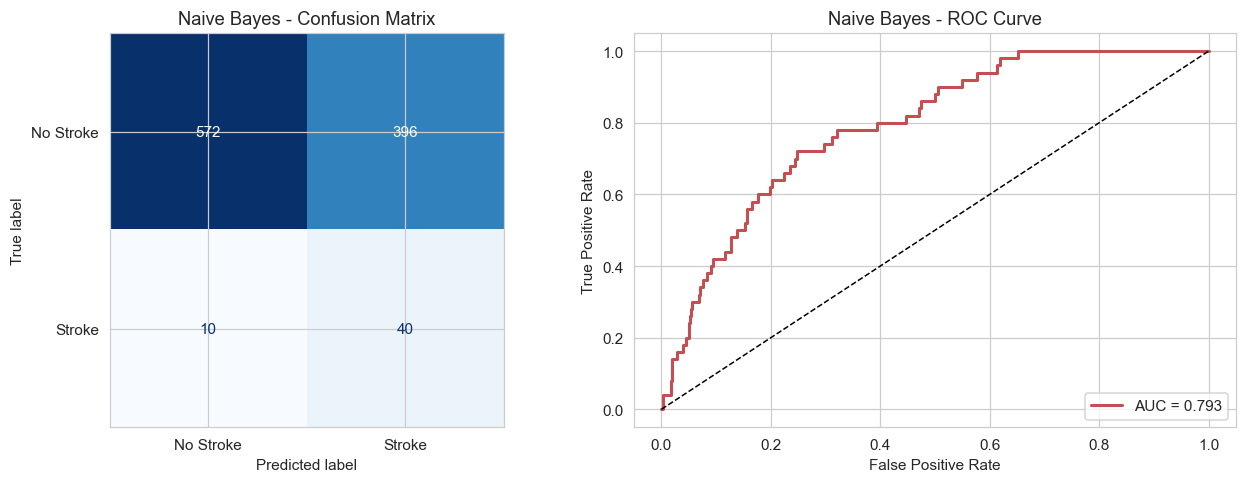

In [54]:
nb = GaussianNB()
nb.fit(X_train_s_res, y_train_s_res)
nb_pred  = nb.predict(X_test_s)
nb_proba = nb.predict_proba(X_test_s)[:, 1]
_, roc = evaluate_model("Naive Bayes", y_test, nb_pred, nb_proba)
roc_store["Naive Bayes"] = roc
plot_cm_roc("Naive Bayes", y_test, nb_pred, nb_proba)

In [55]:
# Comparison Among Models

In [56]:
summary = pd.DataFrame(results).set_index("Model").round(4)
summary = summary.sort_values("ROC-AUC", ascending=False)

def highlight_max(s):
    is_max = s == s.max()
    return ["background-color: #c6efce; font-weight: bold" if v else "" for v in is_max]

summary.style.apply(highlight_max,
    subset=["Accuracy", "Precision", "Recall", "F1-score",
            "Sensitivity", "Specificity", "ROC-AUC"])

,Accuracy,Precision,Recall,F1-score,Sensitivity,Specificity,ROC-AUC
Model,,,,,,,
Logistic Regression,0.706300,0.126100,0.840000,0.219300,0.840000,0.699400,0.844500
Naive Bayes,0.601200,0.091700,0.800000,0.164600,0.800000,0.590900,0.793200
Random Forest,0.886100,0.107100,0.180000,0.134300,0.180000,0.922500,0.773000
Decision Tree (depth=4),0.815300,0.151500,0.600000,0.241900,0.600000,0.826400,0.772900
AdaBoost,0.833000,0.147100,0.500000,0.227300,0.500000,0.850200,0.764300
XGBoost,0.887000,0.150500,0.280000,0.195800,0.280000,0.918400,0.762900
Gradient Boosting,0.881100,0.148500,0.300000,0.198700,0.300000,0.911200,0.731800
KNN (k=5),0.805500,0.084300,0.300000,0.131600,0.300000,0.831600,0.669100


In [57]:
# Best Model Per Metric

In [58]:
print(summary.to_string())
print("\nBest model per metric:")
for col in ["Accuracy", "Precision", "Recall", "F1-score",
            "Sensitivity", "Specificity", "ROC-AUC"]:
    print(f"  {col:12s}: {summary[col].idxmax()} ({summary[col].max():.4f})")

                         Accuracy  Precision  Recall  F1-score  Sensitivity  Specificity  ROC-AUC
Model                                                                                            
Logistic Regression        0.7063     0.1261    0.84    0.2193         0.84       0.6994   0.8445
Naive Bayes                0.6012     0.0917    0.80    0.1646         0.80       0.5909   0.7932
Random Forest              0.8861     0.1071    0.18    0.1343         0.18       0.9225   0.7730
Decision Tree (depth=4)    0.8153     0.1515    0.60    0.2419         0.60       0.8264   0.7729
AdaBoost                   0.8330     0.1471    0.50    0.2273         0.50       0.8502   0.7643
XGBoost                    0.8870     0.1505    0.28    0.1958         0.28       0.9184   0.7629
Gradient Boosting          0.8811     0.1485    0.30    0.1987         0.30       0.9112   0.7318
KNN (k=5)                  0.8055     0.0843    0.30    0.1316         0.30       0.8316   0.6691

Best model per metr

In [59]:
# Grouped Metric Bar Chart

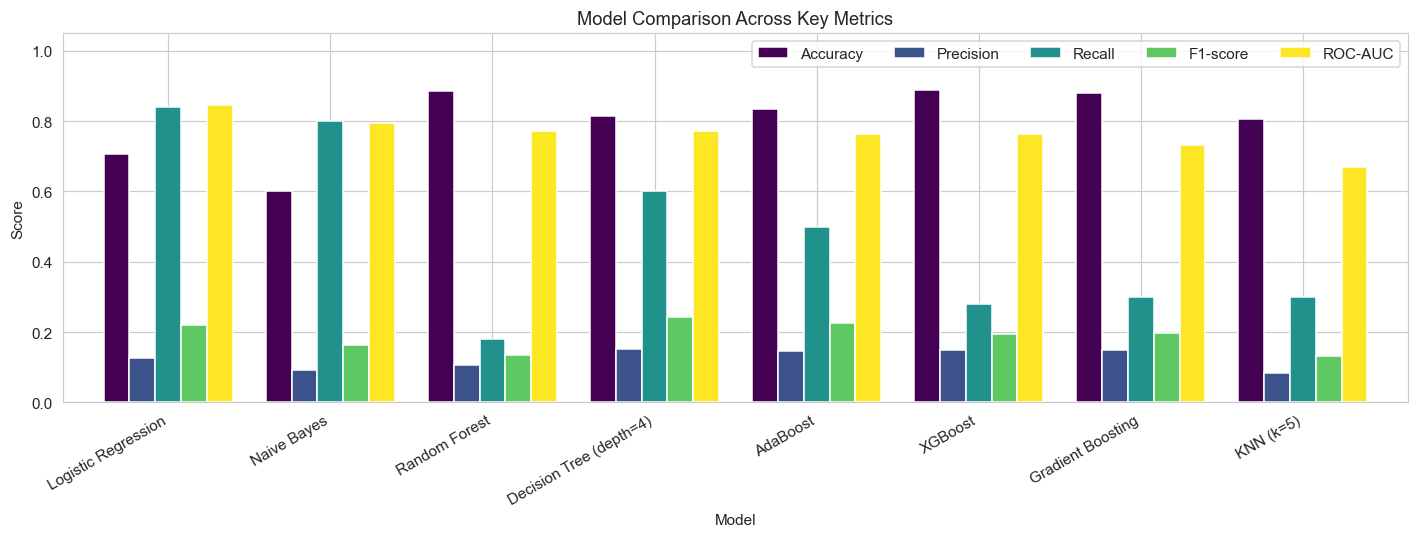

In [60]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
summary[metrics_to_plot].plot.bar(figsize=(13, 5), width=0.8,
                                  colormap="viridis", edgecolor="white")
plt.title("Model Comparison Across Key Metrics")
plt.ylabel("Score"); plt.ylim(0, 1.05); plt.xticks(rotation=30, ha="right")
plt.legend(loc="upper right", ncol=5); plt.tight_layout(); plt.show()

In [61]:
# Combined ROC Curves

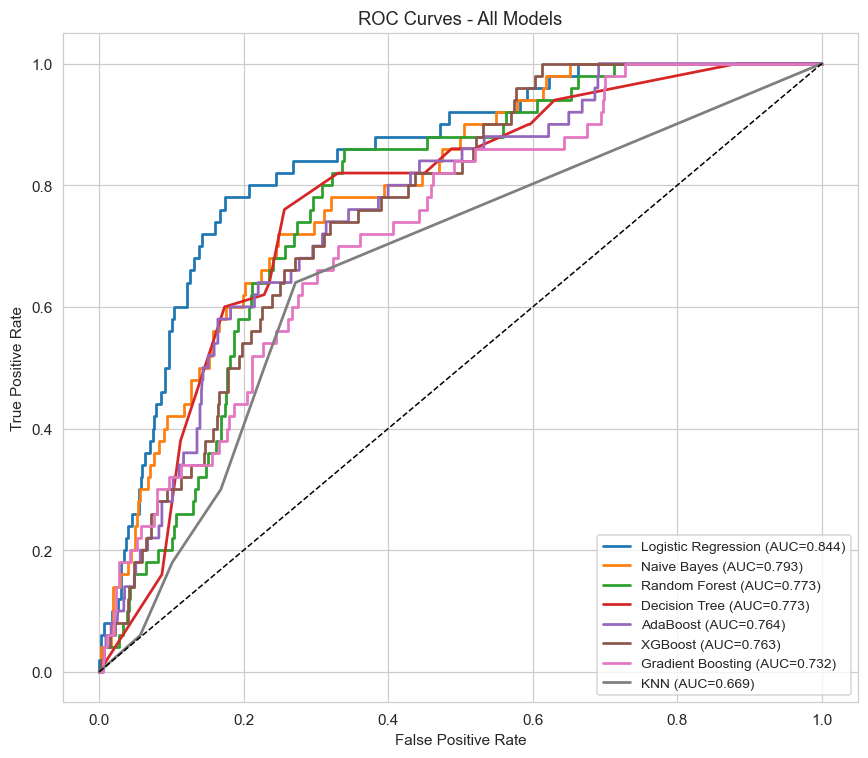

In [62]:
plt.figure(figsize=(8, 7))
for name, (fpr, tpr, a) in sorted(roc_store.items(), key=lambda x: -x[1][2]):
    plt.plot(fpr, tpr, lw=1.8, label=f"{name} (AUC={a:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All Models"); plt.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

In [63]:
# Logistic Regression as a high-recall SCREENING

In [64]:
from sklearn.metrics import precision_recall_curve

lr_proba = lr.predict_proba(X_test_s)[:, 1]

def metrics_at(threshold):
    """Confusion-matrix-derived metrics at a chosen probability cut-off."""
    pred = (lr_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return {
        "Threshold":   threshold,
        "Accuracy":    accuracy_score(y_test, pred),
        "Precision":   precision_score(y_test, pred, zero_division=0),
        "Recall":      recall_score(y_test, pred),
        "F1-score":    f1_score(y_test, pred, zero_division=0),
        "Specificity": tn / (tn + fp) if (tn + fp) else 0,
        "Flagged":     int(pred.sum()),
        "Strokes caught": f"{tp}/{tp+fn}",
    }


TARGET_RECALL = 0.90          
precision, recall, thresholds = precision_recall_curve(y_test, lr_proba)


hits = np.where(recall[:-1] >= TARGET_RECALL)[0]
screening_threshold = thresholds[hits[-1]] if len(hits) else 0.0


f1_curve = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)
balanced_threshold = thresholds[int(np.argmax(f1_curve))]


comparison = pd.DataFrame([
    {"Strategy": "Default cut-off",              **metrics_at(0.50)},
    {"Strategy": f"Screening (recall ≥ {TARGET_RECALL:.0%})", **metrics_at(screening_threshold)},
    {"Strategy": "Balanced (max F1)",            **metrics_at(balanced_threshold)},
]).set_index("Strategy")
print(comparison.round(3).to_string())

                          Threshold  Accuracy  Precision  Recall  F1-score  Specificity  Flagged Strokes caught
Strategy                                                                                                       
Default cut-off               0.500     0.706      0.126    0.84     0.219        0.699      333          42/50
Screening (recall ≥ 90%)      0.252     0.546      0.090    0.90     0.163        0.528      502          45/50
Balanced (max F1)             0.810     0.882      0.231    0.60     0.333        0.897      130          30/50


In [65]:
# Visualise the precision/recall/specificity trade-off vs threshold

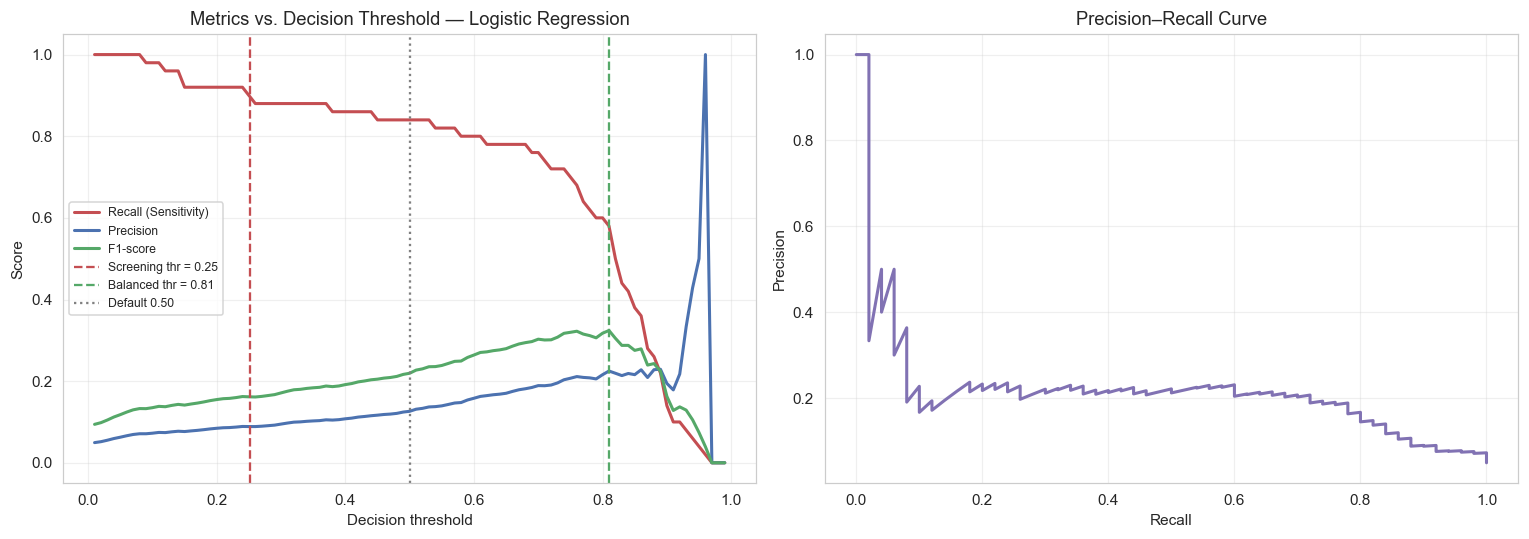

In [66]:
grid = np.linspace(0.01, 0.99, 99)
prec_g = [precision_score(y_test, (lr_proba >= t).astype(int), zero_division=0) for t in grid]
rec_g  = [recall_score(y_test,    (lr_proba >= t).astype(int)) for t in grid]
f1_g   = [f1_score(y_test,        (lr_proba >= t).astype(int), zero_division=0) for t in grid]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(grid, rec_g,  label="Recall (Sensitivity)", lw=2, color="#C44E52")
ax[0].plot(grid, prec_g, label="Precision",            lw=2, color="#4C72B0")
ax[0].plot(grid, f1_g,   label="F1-score",             lw=2, color="#55A868")
ax[0].axvline(screening_threshold, ls="--", color="#C44E52",
              label=f"Screening thr = {screening_threshold:.2f}")
ax[0].axvline(balanced_threshold,  ls="--", color="#55A868",
              label=f"Balanced thr = {balanced_threshold:.2f}")
ax[0].axvline(0.50, ls=":", color="gray", label="Default 0.50")
ax[0].set_xlabel("Decision threshold"); ax[0].set_ylabel("Score")
ax[0].set_title("Metrics vs. Decision Threshold — Logistic Regression")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

ax[1].plot(recall, precision, lw=2, color="#8172B3")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
ax[1].set_title("Precision–Recall Curve")
ax[1].grid(alpha=.3)

plt.tight_layout(); plt.show()

In [67]:
# Flag at-risk patients for follow-up at the screening cut-off

In [68]:
risk_scores = pd.DataFrame({
    "stroke_probability": lr_proba,
    "actual_stroke": y_test.values,
}, index=y_test.index)
risk_scores["FLAG_for_followup"] = (risk_scores["stroke_probability"] >= screening_threshold).astype(int)

# Rank the highest-risk patients first
risk_scores = risk_scores.sort_values("stroke_probability", ascending=False)

n_flagged = int(risk_scores["FLAG_for_followup"].sum())
print(f"Screening threshold: {screening_threshold:.3f}")
print(f"Patients flagged for follow-up: {n_flagged} of {len(risk_scores)} "
      f"({n_flagged/len(risk_scores):.1%} of the test population)")
print(f"True strokes captured in the flagged group: "
      f"{int(risk_scores.loc[risk_scores.FLAG_for_followup==1, 'actual_stroke'].sum())} "
      f"of {int(risk_scores['actual_stroke'].sum())}")
risk_scores.head(15)

Screening threshold: 0.252
Patients flagged for follow-up: 502 of 1018 (49.3% of the test population)
True strokes captured in the flagged group: 45 of 50


,stroke_probability,actual_stroke,FLAG_for_followup
187,0.963732,1,1
3533,0.957733,0,1
1240,0.951017,0,1
76,0.950115,1,1
3670,0.948220,0,1
17,0.947431,1,1
313,0.942397,0,1
3385,0.937552,0,1
4742,0.936747,0,1
2676,0.932305,0,1


## Conclusion

This study trained and compared eight classification algorithms — Logistic Regression, Decision Tree, Random Forest, AdaBoost, Gradient Boosting, XGBoost, K-Nearest Neighbors, and Naïve Bayes — to predict stroke from patient health records. The defining characteristic of the problem is severe class imbalance: only ~4.9% of patients had a stroke, addressed by applying SMOTE to the training set only, leaving the test set at its true prevalence so all reported metrics reflect real-world performance.

**Reading the results correctly.** Because strokes are rare, accuracy is not a meaningful ranking metric — a model that predicts "no stroke" for everyone would still score ~95%. The clinically relevant metrics are Recall/Sensitivity (the share of real strokes detected) and ROC-AUC (overall ranking ability). Precision is low for every model, the unavoidable consequence of a rare positive class combined with SMOTE: most positive predictions are false alarms, and that trade-off is acceptable when the goal is to avoid missing strokes.

**Best overall performer.** Logistic Regression provided the strongest balance, achieving the highest ROC-AUC (0.845) and the highest recall/sensitivity (0.840) — correctly identifying 42 of 50 strokes in the held-out test set — while remaining fully interpretable through its coefficient and p-value table. For a screening task where a missed stroke is far costlier than a false alarm, this high-sensitivity behavior is exactly what is wanted. The boosting methods and Random Forest posted solid AUCs with higher specificity (XGBoost reached 0.887 accuracy and 0.918 specificity) but caught far fewer true strokes at the default threshold.

**Trade-off summary.**
- **Highest sensitivity / recall:** Naïve Bayes (recall 0.80, flags nearly everyone — useful only as a first-pass filter) and Logistic Regression (a far more balanced high-recall option).
- **Highest specificity / precision:** the tree ensembles (Random Forest specificity 0.923; Decision Tree best precision 0.152 and best F1 0.242) — they raise fewer false alarms but miss more strokes.
- **Best AUC:** Logistic Regression, with the boosting models close behind.
- **Weakest:** KNN (AUC 0.669), sensitive to the high-dimensional encoding and synthetic neighborhoods.

**Consistent finding across every algorithm.** Age is the dominant predictor of stroke, followed by average glucose level and hypertension — the only three predictors that reached statistical significance (p < 0.05) in the logistic model. Lifestyle and demographic variables (residence, work type, smoking, marital status) added little once age was accounted for, and all variance-inflation factors were well below 5, confirming the estimates are not distorted by multicollinearity.

**Practical recommendation.** Deploy a high-recall model (Logistic Regression) as a screening stage to flag at-risk patients for follow-up, accepting the false alarms. Tuning the decision threshold from the default 0.50 down to ~0.25 raised stroke detection from 42 to 45 of 50 cases (90% recall); if a sharper precision/recall balance is later needed, the threshold can be moved toward the F1-optimal point without retraining the model. In short, threshold tuning — not model replacement — is the right lever for matching the classifier to the clinical cost of a missed stroke.

**Limitations and future work.** The dataset is observational (associations, not causes), contains only 249 stroke cases (limiting power to detect weaker predictors), and relies on SMOTE's synthetic minority examples. Future improvements include probability calibration before threshold selection, cost-sensitive learning that encodes the false-negative/false-positive cost ratio directly, an age-by-glucose interaction term, and external validation on an independent patient cohort.